# NinaPro DB5 Exercise A 完整动作序列（简化版）

这个 Notebook 将 Exercise A 中的每次动作保留为一条**变长完整序列**，不做滑窗、补零、截断、滤波或归一化。

- 输入：10 名受试者的 `S*_E1_A1.mat` 文件
- 划分：重复次数 1、3、4、6 用于训练，2、5 用于测试
- 标签：原始动作编号 1～12 转换为模型标签 0～11
- 输出：`train.npz`、`test.npz` 和 `metadata.json`


## 1. 导入依赖并设置路径

In [ ]:
from pathlib import Path
import json
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.io import loadmat

# 寻找项目根目录
def find_project_root():
    """从当前目录向上查找项目根目录，兼容从项目根目录或 code 目录启动。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 和 ninapro_data 的项目根目录。")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "ninapro_data" / "raw"
ARCHIVE_DIR = RAW_DIR / "archives"
MAT_DIR = RAW_DIR / "exerciseA"
OUTPUT_DIR = PROJECT_ROOT / "ninapro_data" / "processed" / "exerciseA" / "full_sequence"

for directory in (ARCHIVE_DIR, MAT_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SUBJECT_IDS = range(1, 11)  # 对应于NinaPro DB5的10名受试者
SAMPLE_RATE = 200
N_CHANNELS = 16
TRAIN_REPETITIONS = (1, 3, 4, 6)
TEST_REPETITIONS = (2, 5)

GESTURE_NAMES = {
    1: "食指屈曲", 2: "食指伸展",
    3: "中指屈曲", 4: "中指伸展",
    5: "无名指屈曲", 6: "无名指伸展",
    7: "小指屈曲", 8: "小指伸展",
    9: "拇指内收", 10: "拇指外展",
    11: "拇指屈曲", 12: "拇指伸展",
}

print(f"项目根目录：{PROJECT_ROOT}")
print(f"结果保存目录：{OUTPUT_DIR}")


项目根目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro
结果保存目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\full_sequence


## 2. 准备 Exercise A 原始文件

如果 MAT 文件已经存在则直接复用；否则先下载对应 ZIP，再只解压 Exercise A 文件。

In [3]:
def zip_is_valid(path):
    """确认压缩包存在且没有损坏。"""
    try:
        with zipfile.ZipFile(path) as archive:
            return archive.testzip() is None
    except (FileNotFoundError, zipfile.BadZipFile, OSError):
        return False


def download_archive(subject_id):
    """在本地没有有效压缩包时，从官方源或备用源下载。"""
    archive_path = ARCHIVE_DIR / f"s{subject_id}.zip"
    if zip_is_valid(archive_path):
        return archive_path

    urls = [
        f"https://ninapro.hevs.ch/files/DB5_Preproc/s{subject_id}.zip",
        f"https://zenodo.org/records/1000116/files/s{subject_id}.zip?download=1",
    ]
    temporary_path = archive_path.with_suffix(".zip.part")
    last_error = None

    for url in urls:
        try:
            print(f"正在下载 S{subject_id}：{url}")
            # 先写入临时文件，避免下载中断后留下看似完整的 ZIP。
            with requests.get(url, stream=True, timeout=(20, 180)) as response:
                response.raise_for_status()
                with temporary_path.open("wb") as file_handle:
                    for chunk in response.iter_content(1024 * 1024):
                        if chunk:
                            file_handle.write(chunk)
            if not zip_is_valid(temporary_path):
                raise zipfile.BadZipFile("下载的 ZIP 文件不完整。")
            temporary_path.replace(archive_path)
            return archive_path
        except (requests.RequestException, OSError, zipfile.BadZipFile) as error:
            last_error = error
            temporary_path.unlink(missing_ok=True)

    raise RuntimeError(f"S{subject_id} 下载失败：{last_error}")


def prepare_mat_file(subject_id):
    """返回一名受试者的 Exercise A MAT 文件路径。"""
    file_name = f"S{subject_id}_E1_A1.mat"
    mat_path = MAT_DIR / file_name
    if mat_path.is_file() and mat_path.stat().st_size > 0:
        return mat_path

    archive_path = download_archive(subject_id)
    with zipfile.ZipFile(archive_path) as archive:
        # ZIP 内可能带有子目录，因此只比较文件名。
        members = [name for name in archive.namelist() if Path(name).name.lower() == file_name.lower()]
        if len(members) != 1:
            raise FileNotFoundError(f"{archive_path.name} 中未找到唯一的 {file_name}。")
        with archive.open(members[0]) as source, mat_path.open("wb") as target:
            shutil.copyfileobj(source, target)
    return mat_path


mat_paths = {subject_id: prepare_mat_file(subject_id) for subject_id in SUBJECT_IDS}
print(f"已准备 {len(mat_paths)} 个 Exercise A 文件。")
mat_paths


已准备 10 个 Exercise A 文件。


{1: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S1_E1_A1.mat'),
 2: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S2_E1_A1.mat'),
 3: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S3_E1_A1.mat'),
 4: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S4_E1_A1.mat'),
 5: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S5_E1_A1.mat'),
 6: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S6_E1_A1.mat'),
 7: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S7_E1_A1.mat'),
 8: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S8_E1_A1.mat'),
 9: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data/raw/exerciseA/S9_E1_A1.mat'),
 10: WindowsPath('C:/Users/Fortyfour/Desktop/SNN_for_Ninapro/ninapro_data

## 3. 提取完整动作序列

连续且具有相同动作标签、重复编号的采样点组成一条完整动作序列；标签 0 表示静息，不写入数据集。

In [4]:
def extract_subject_sequences(subject_id, mat_path):
    """从一名受试者的数据中提取 12 个动作的 6 次完整重复。"""
    data = loadmat(mat_path, variable_names=["emg", "restimulus", "rerepetition"])
    emg = np.asarray(data["emg"], dtype=np.float32) # (N, 16)
    stimulus = np.asarray(data["restimulus"]).reshape(-1).astype(np.int16) # (N,)
    repetition = np.asarray(data["rerepetition"]).reshape(-1).astype(np.int8) # (N,)

    if emg.shape != (len(stimulus), N_CHANNELS) or len(repetition) != len(stimulus):
        raise ValueError(f"S{subject_id} 的数据形状不一致。")
    if not np.isfinite(emg).all():
        raise ValueError(f"S{subject_id} 的 EMG 中包含 NaN 或无穷值。")

    # 标签或重复编号变化时，说明上一条连续序列已经结束。
    boundary = np.ones(len(stimulus), dtype=bool)
    boundary[1:] = (stimulus[1:] != stimulus[:-1]) | (repetition[1:] != repetition[:-1])
    starts = np.flatnonzero(boundary)   # 返回所有值为True的索引，即每个新序列的起始位置
    ends = np.r_[starts[1:], len(stimulus)] # 返回每个新序列的结束位置（不包含），最后一个序列的结束位置为总长度

    sequences = []
    for start, end in zip(starts, ends):
        raw_label = int(stimulus[start])
        repeat_id = int(repetition[start])
        if raw_label == 0:
            continue
        sequences.append({
            "X": emg[start:end].copy(),       # 形状：[时间点, 16 个通道]
            "y": raw_label - 1,              # 模型标签使用 0～11
            "subject": subject_id,  # 受试者编号
            "repetition": repeat_id,    # 重复编号
            "start_sample": int(start), # 起始样本索引
            "end_sample": int(end),     # 结束样本索引
        })
    return sequences


sequences = []
for subject_id, mat_path in mat_paths.items():
    sequences.extend(extract_subject_sequences(subject_id, mat_path))

# 每名受试者应包含 12 个动作 × 6 次重复，且每个组合只出现一次。
sequence_keys = {(item["subject"], item["y"], item["repetition"]) for item in sequences}
assert len(sequences) == 10 * 12 * 6    
assert len(sequence_keys) == len(sequences)

lengths = np.asarray([len(item["X"]) for item in sequences])
summary = pd.DataFrame({
    "序列数量": [len(sequences)],
    "最短长度": [lengths.min()],
    "中位长度": [int(np.median(lengths))],
    "最长长度": [lengths.max()],
    "中位时长（秒）": [round(np.median(lengths) / SAMPLE_RATE, 3)],
})
summary


,序列数量,最短长度,中位长度,最长长度,中位时长（秒）
0,720,422,736,2779,3.68


## 4. 查看序列分布

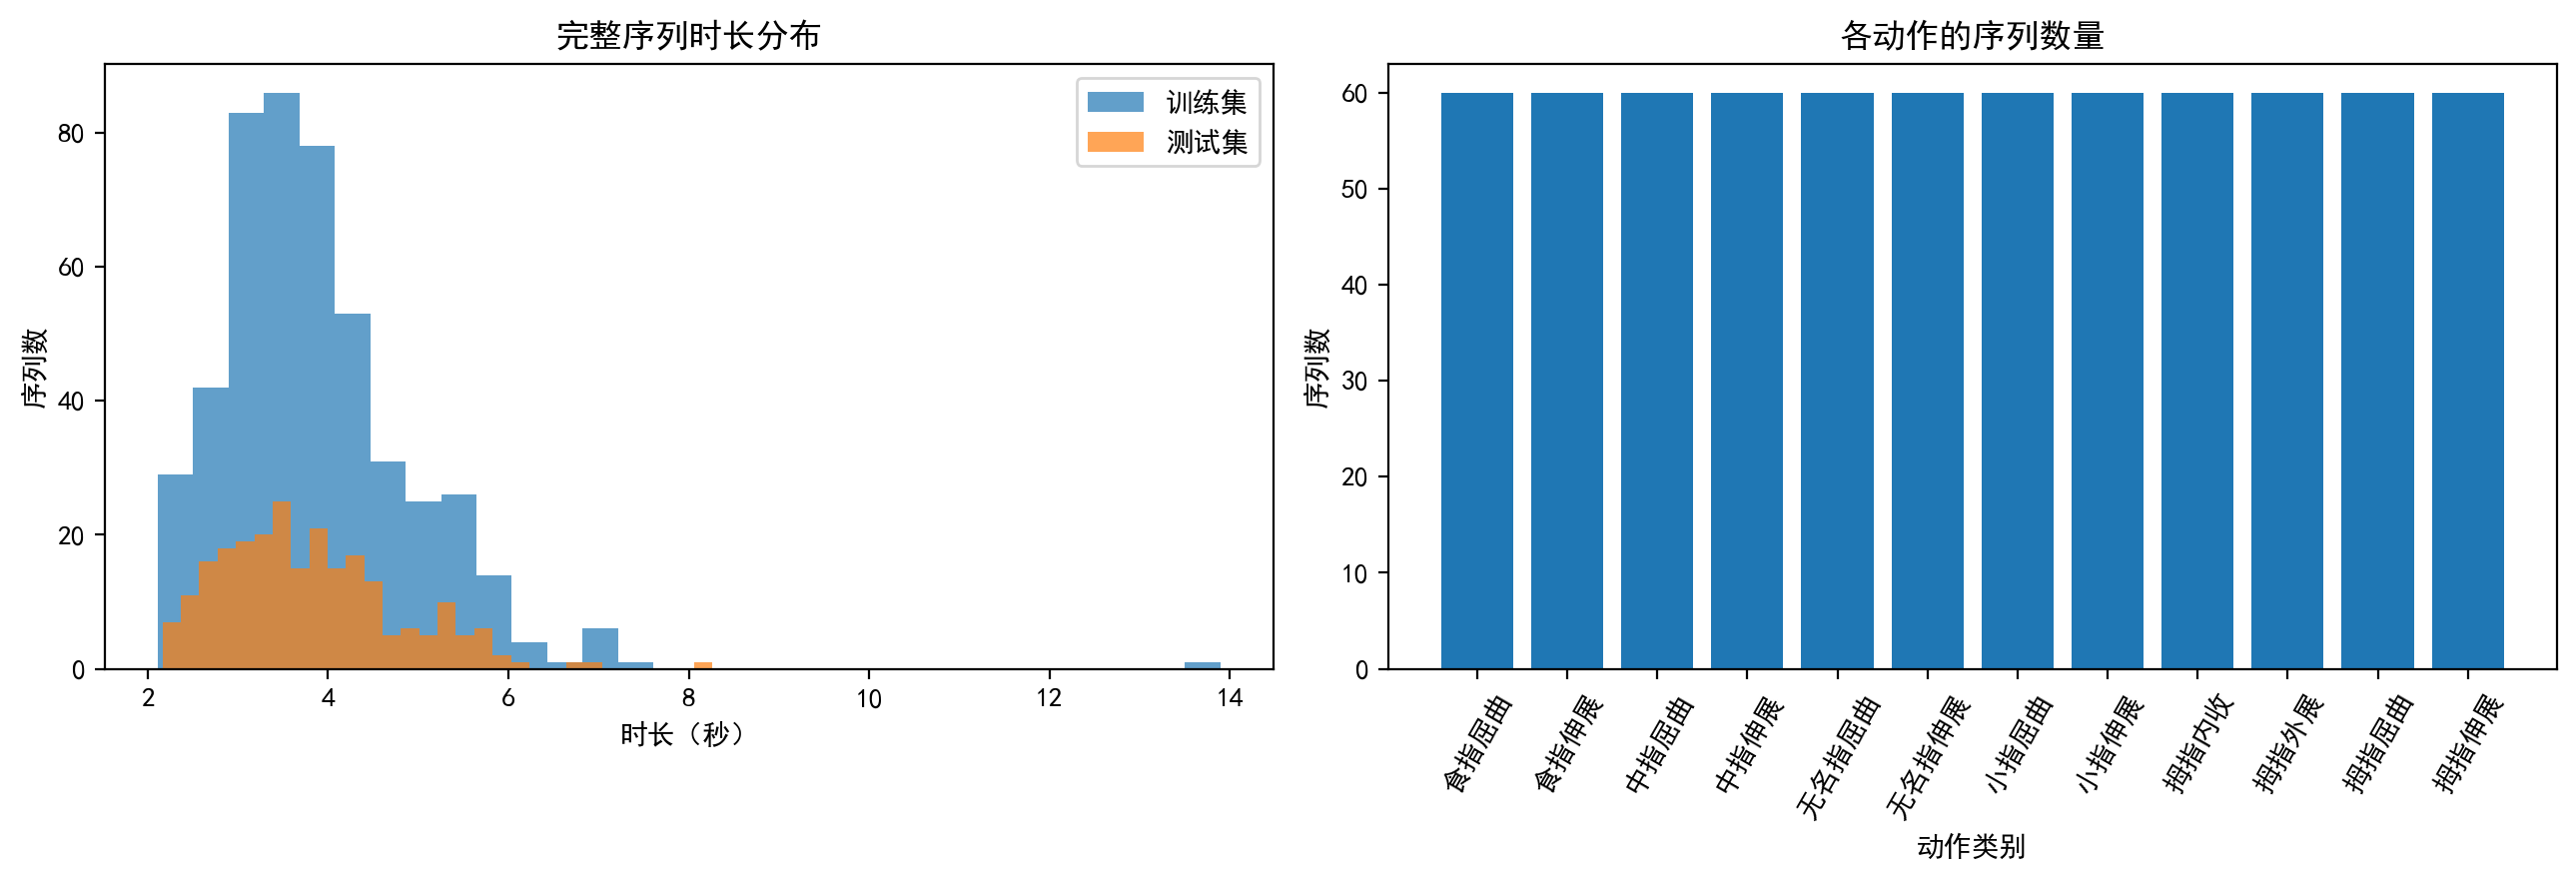

In [7]:
train_lengths = [len(item["X"]) / SAMPLE_RATE for item in sequences if item["repetition"] in TRAIN_REPETITIONS]
test_lengths = [len(item["X"]) / SAMPLE_RATE for item in sequences if item["repetition"] in TEST_REPETITIONS]
class_counts = np.bincount([item["y"] for item in sequences], minlength=12)

# 添加中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=200)
axes[0].hist(train_lengths, bins=30, alpha=0.7, label="训练集")
axes[0].hist(test_lengths, bins=30, alpha=0.7, label="测试集")
axes[0].set(title="完整序列时长分布", xlabel="时长（秒）", ylabel="序列数")
axes[0].legend()

axes[1].bar(range(12), class_counts)
axes[1].set(title="各动作的序列数量", xlabel="动作类别", ylabel="序列数")
axes[1].set_xticks(range(12), [GESTURE_NAMES[i] for i in range(1, 13)], rotation=60)

fig.tight_layout()
plt.show()


## 5. 划分并保存数据

不同序列的长度不同。这里将所有序列首尾相接保存到 `X`，用 `offsets[i]:offsets[i+1]` 记录第 `i` 条序列的位置，从而避免补零。

In [9]:
def pack_sequences(items):
    """把变长序列打包为可直接写入 NPZ 的数组字典。"""
    lengths = np.asarray([len(item["X"]) for item in items], dtype=np.int32)
    offsets = np.r_[0, np.cumsum(lengths, dtype=np.int64)]
    return {
        "X": np.concatenate([item["X"] for item in items]).astype(np.float32, copy=False),  # 形状：[总时间点, 16 通道]
        "offsets": offsets,
        "lengths": lengths,
        "y": np.asarray([item["y"] for item in items], dtype=np.int64),
        "subject": np.asarray([item["subject"] for item in items], dtype=np.int16),
        "repetition": np.asarray([item["repetition"] for item in items], dtype=np.int8),
        "start_sample": np.asarray([item["start_sample"] for item in items], dtype=np.int32),
        "end_sample": np.asarray([item["end_sample"] for item in items], dtype=np.int32),
    }


train_items = [item for item in sequences if item["repetition"] in TRAIN_REPETITIONS]
test_items = [item for item in sequences if item["repetition"] in TEST_REPETITIONS]
datasets = {"train": pack_sequences(train_items), "test": pack_sequences(test_items)}

for split_name, dataset in datasets.items():
    np.savez_compressed(OUTPUT_DIR / f"{split_name}.npz", **dataset)
    print(f"{split_name}: {len(dataset['y'])} 条序列，X 形状为 {dataset['X'].shape}")

metadata = {
    "dataset": "NinaPro DB5",
    "exercise": "A / E1",
    "sample_rate_hz": SAMPLE_RATE,
    "channels": N_CHANNELS,
    "subjects": list(SUBJECT_IDS),
    "train_repetitions": list(TRAIN_REPETITIONS),
    "test_repetitions": list(TEST_REPETITIONS),
    "rest_included": False,
    "normalized": False,
    "storage": "第 i 条序列为 X[offsets[i]:offsets[i + 1]]，形状为 [时间点, 16 通道]",
    "label_mapping": {
        str(raw_label - 1): {"raw_label": raw_label, "name_zh": GESTURE_NAMES[raw_label]}
        for raw_label in range(1, 13)
    },
}

with (OUTPUT_DIR / "metadata.json").open("w", encoding="utf-8") as file_handle:
    json.dump(metadata, file_handle, ensure_ascii=False, indent=2)

print(f"数据已保存到：{OUTPUT_DIR}")


train: 480 条序列，X 形状为 (370986, 16)
test: 240 条序列，X 形状为 (182648, 16)
数据已保存到：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\full_sequence


## 6. 重新加载并验证

保存后重新读取文件，检查序列数量、边界、标签、受试者和重复编号，避免把写盘问题带入训练阶段。

In [10]:
def validate_dataset(path, allowed_repetitions):
    """读取并验证一个完整序列数据文件。"""
    with np.load(path, allow_pickle=False) as loaded:
        data = {name: loaded[name] for name in loaded.files}

    expected_count = 10 * 12 * len(allowed_repetitions)
    assert data["X"].ndim == 2 and data["X"].shape[1] == N_CHANNELS
    assert data["X"].dtype == np.float32 and np.isfinite(data["X"]).all()
    assert len(data["y"]) == expected_count
    assert data["offsets"][0] == 0 and data["offsets"][-1] == len(data["X"])
    assert np.array_equal(np.diff(data["offsets"]), data["lengths"])
    assert set(np.unique(data["y"])) == set(range(12))
    assert set(np.unique(data["subject"])) == set(SUBJECT_IDS)
    assert set(np.unique(data["repetition"])) == set(allowed_repetitions)
    assert np.array_equal(data["end_sample"] - data["start_sample"], data["lengths"])
    return data


saved_train = validate_dataset(OUTPUT_DIR / "train.npz", TRAIN_REPETITIONS)
saved_test = validate_dataset(OUTPUT_DIR / "test.npz", TEST_REPETITIONS)

# 演示如何用 offsets 恢复第一条变长序列。
first_sequence = saved_train["X"][saved_train["offsets"][0]:saved_train["offsets"][1]]
print("验证通过。")
print("训练/测试序列数：", len(saved_train["y"]), len(saved_test["y"]))
print("第一条训练序列形状：", first_sequence.shape)


验证通过。
训练/测试序列数： 480 240
第一条训练序列形状： (787, 16)


## 7. PyTorch 读取示例（可选）

`Dataset` 按需恢复单条序列；`collate_full_sequences` 只在组成批次时把序列补到当前批次的最大长度。

In [11]:
try:
    import torch
    from torch.nn.utils.rnn import pad_sequence
    from torch.utils.data import Dataset

    class FullSequenceDataset(Dataset):
        def __init__(self, npz_path):
            with np.load(npz_path, allow_pickle=False) as loaded:
                self.X = loaded["X"]
                self.offsets = loaded["offsets"]
                self.y = loaded["y"]

        def __len__(self):
            return len(self.y)

        def __getitem__(self, index):
            start, end = self.offsets[index:index + 2]
            # 神经网络常用 [通道, 时间]，因此在读取时进行转置。
            sequence = torch.from_numpy(self.X[start:end].copy()).T
            return sequence, int(self.y[index])

    def collate_full_sequences(batch):
        """把变长样本整理为 [批次, 通道, 时间]，同时返回真实长度。"""
        sequences, labels = zip(*batch)
        lengths = torch.tensor([sequence.shape[1] for sequence in sequences])
        padded = pad_sequence(
            [sequence.T for sequence in sequences],
            batch_first=True,
        ).transpose(1, 2)
        return padded, torch.tensor(labels), lengths

    train_dataset = FullSequenceDataset(OUTPUT_DIR / "train.npz")
    example_X, example_y = train_dataset[0]
    print("单条序列：", tuple(example_X.shape), "标签：", example_y)
except ModuleNotFoundError:
    print("当前环境未安装 PyTorch；前面的 NPZ 数据仍可正常使用。")


单条序列： (16, 787) 标签： 0
